[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/rl-basics/blob/main/MDP_introduction_frozenlake.ipynb)

In [ ]:
#%pip install --upgrade pygame
#%pip install "setuptools"

# A coding introduction to the Markov Decision Process


## The problem we are trying to solve

Before any algorithm, we need a **task**. Throughout this course the task is the classic **Frozen Lake**.

**The story.** An elf is standing on the top-left corner of a **4x4 frozen lake**. Somewhere on the lake there is a **gift** (the goal, in the bottom-right corner), but the ice has **holes**: step into one and the episode is over. The elf can move **LEFT, DOWN, RIGHT, or UP**; a move that would leave the grid keeps the elf where it is. We want the elf to reach the gift **without falling into a hole**.

We use `is_slippery=False`, so the ice is *not* slippery: every move goes exactly where the elf intends. This makes the world **deterministic**, which is the right place to start learning.

**Why this is a Markov Decision Process (MDP).** Every reinforcement-learning task is described by five ingredients, and Frozen Lake has all of them:

| MDP ingredient | In Frozen Lake |
|---|---|
| **States** *s* | The square the elf is on, numbered **0 to 15** (left to right, top to bottom) &mdash; so 16 states in total. |
| **Actions** *a* | The four moves: 0 = LEFT, 1 = DOWN, 2 = RIGHT, 3 = UP. |
| **Transitions** | Where a move takes the elf. With `is_slippery=False` it is *deterministic*: a legal move always succeeds, and a move off the grid leaves the elf where it was. |
| **Reward** *r* | **0 for every step**, and **+1 only when the gift is reached**. This is called a *sparse* reward: the environment stays silent until the very end. |
| **Terminal states** | The **gift** (square 15, reward +1) and every **hole** (reward 0). Reaching any of them **ends the episode**. |

**What "solving" means.** We want a **policy** &mdash; a rule that tells the elf which action to take on each square &mdash; that reaches the gift with the **largest total reward**. Because the only reward is +1 at the gift (discounted by how long it took), the best policy reaches the gift as quickly as possible while avoiding the holes. The rest of the course is a tour of different methods for *finding* that policy: starting from methods that need to know the lake's rules in advance (dynamic programming), moving to methods that learn purely from trial-and-error experience (Monte-Carlo, SARSA, Q-Learning), and finally to deep neural networks.

This first notebook simply gets us comfortable with the **Gymnasium interface** &mdash; the three methods `reset()`, `step()` and `render()` &mdash; that every later notebook reuses.

In [ ]:
# @title Setup code (not important) - Run this cell by pressing "Shift + Enter"

# Install Gymnasium (the maintained successor of the old Gym library).
%pip install -qq gymnasium==1.3.0 pygame

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation

from IPython.display import HTML

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pygame")


def display_video(frames):
    # Turn a list of RGB frames into an HTML5 video the notebook can play inline.
    # Copied from: https://colab.research.google.com/github/deepmind/dm_control/blob/master/tutorial.ipynb
    orig_backend = matplotlib.get_backend()      # Remember the interactive backend.
    matplotlib.use('Agg')                        # Switch to a non-GUI backend to build the frames.
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    matplotlib.use(orig_backend)                 # Restore the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])                    # Show the first frame.
    def update(frame):
        im.set_data(frame)                       # Each animation tick swaps in the next frame.
        return [im]
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=250, blit=True, repeat=False)
    return HTML(anim.to_html5_video())

## Quick view of the Gymnasium library:
<br/>
<br/>

Gymnasium is a library for reinforcement learning research (it is the actively maintained successor of OpenAI's Gym). It provides us with a simple interface to a large number of tasks, including

- Classic control tasks (CartPole, Pendulum, MountainCar, etc)
- Classic video games (Space Invaders, Breakout, Pong, etc)
- Continuous control tasks
- Robotic arm manipulation

In this section we are going to get familiar with the methods that we'll use while solving a control
task.


<br/>
<br/>


![title](https://github.com/escape-velocity-labs/beginner_master_rl/blob/main/img/mdp_diagram.svg?raw=1)

###### Source: https://upload.wikimedia.org/wikipedia/commons/1/1b/Reinforcement_learning_diagram.svg

##### Making the environment: gym.make("FrozenLake-v1")

An **environment** is the world the agent lives in. It holds the current
situation (the *state*), accepts the agent's moves (the *actions*), and hands
back a *reward* plus the next state after each move.

In Gymnasium we create an environment by passing its name to `gym.make`. Here
we ask for `FrozenLake-v1` with two extra settings:

- `is_slippery=False` &mdash; the ice is not slippery, so moves are **deterministic**.
- `render_mode="rgb_array"` &mdash; in Gymnasium the render mode is chosen **once, at
  creation time** (in the old Gym it was passed to `render()` on every call).
  `"rgb_array"` means `render()` will return the picture as a NumPy array of
  pixels, which we can display with Matplotlib.

Either way we get a `gym.Env` object that we will talk to through just three
methods: `reset()`, `step()` and `render()`.

In [1]:
import gymnasium as gym
import numpy as np
from IPython import display
from matplotlib import pyplot as plt

%matplotlib inline

In [2]:
# Build a fresh Frozen Lake environment. 'env' is the world the agent will act in.
# is_slippery=False -> moves are deterministic (the elf goes exactly where it intends).
# render_mode="rgb_array" -> render() will return pictures as pixel arrays.
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

###### env.reset()

`reset()` starts a **new episode**. It puts the elf back on the starting
square and returns **two things**:

- the starting **state**, so the agent knows where it begins, and
- an **info** dictionary with extra details (we can usually ignore it).

This is a change from the old Gym, where `reset()` returned only the state.
`reset()` also accepts a `seed` argument: passing the same seed makes the
episode reproducible, which is very useful when debugging. Call `reset()` once
at the start of every episode, before taking any steps.

In [3]:
# reset() puts the lake back to the start and tells us the starting square.
# It returns TWO values in Gymnasium: the state and an info dictionary.
# seed=42 makes the episode reproducible (same seed -> same randomness).
initial_state, info = env.reset(seed=42)
# Print that starting square so we can see where the episode begins.
print(f"The new episode will start in state: {initial_state}")

The new episode will start in state: 0


##### env.render()

`render()` draws the environment as it looks **right now**. Because we created
the environment with `render_mode="rgb_array"`, it returns the picture as a
NumPy array of pixels, which we can then display with Matplotlib. (Note the
difference from the old Gym: the mode is no longer passed to `render()`
itself.) It is purely for our eyes; the agent does not need it to learn.

C:\Anaconda\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


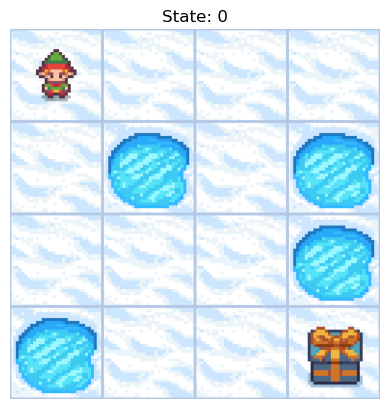

In [4]:
# render() returns a picture (an array of pixels) of the lake right now.
frame = env.render()
# Hide the x/y axis numbers; they mean nothing for a lake picture.
plt.axis('off')
# Put the current state in the title so we know which square is shown.
plt.title(f"State: {initial_state}")
# Draw the picture in the notebook.
plt.imshow(frame)

##### env.step()

`step(action)` is the heart of the loop: it carries out the chosen **action**
and moves the world forward one tick. In Gymnasium it hands back a tuple of
**five** things (the old Gym returned four):

- **next state** &mdash; the square the elf is on after the move.
- **reward** &mdash; the numerical feedback for that move (here 0 for every step, +1 only on reaching the gift).
- **terminated** &mdash; `True` if the episode ended *because of the task itself*: the elf reached the gift or fell into a hole.
- **truncated** &mdash; `True` if the episode was *cut short from outside*: Frozen Lake has a 100-step time limit, and hitting it truncates the episode even though the task did not really end.
- **info** &mdash; an extra dictionary for any other details.

The old single `done` flag was split into `terminated` and `truncated` because
they mean different things (a real ending vs. running out of time). Whenever we
just need to know "is the episode over?", we combine them:
`done = terminated or truncated`.

The basic interaction loop of all RL is simply: *observe state &rarr; choose
action &rarr; call `step` &rarr; repeat until `done`.*

In [5]:
# Choose action 1, which in Frozen Lake means "move down".
# (Careful: the numbering here is 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP.)
action = 1
# step() applies the action and returns FIVE things in Gymnasium: the new square,
# the reward, whether the task itself ended (terminated), whether the time limit
# cut it short (truncated), and an extra-info dictionary.
next_state, reward, terminated, truncated, info = env.step(action)
# Combine the two ending flags: the episode is over if either one is True.
done = terminated or truncated
# Show where the agent ended up after moving down (one row down = state + 4).
print(f"After moving down 1 row, the agent is in state: {next_state}")
# Show the reward we got for that move (0 for every step; +1 only at the gift).
print(f"After moving down 1 row, we got a reward of: {reward}")
# Tell us whether that move ended the episode.
print("After moving down 1 row, the task is", "" if done else "not", "finished")

After moving down 1 row, the agent is in state: 4
After moving down 1 row, we got a reward of: 0
After moving down 1 row, the task is not finished


###### Render the new state

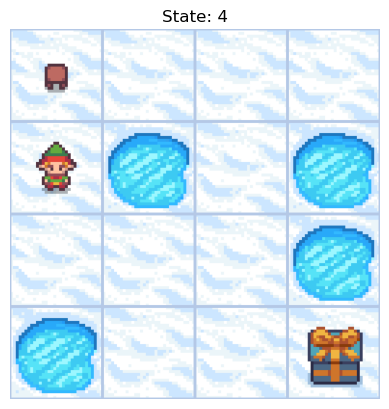

In [6]:
# Take a fresh picture of the lake now that the agent has moved.
frame = env.render()
# Hide the axis numbers.
plt.axis('off')
# Title shows the new state after the step.
plt.title(f"State: {next_state}")
# Draw the updated lake.
plt.imshow(frame)

##### env.close()

`close()` ends the session and releases any resources the environment was
using (windows, drawing surfaces, and so on). Call it when you are finished
with an environment.

In [7]:
# close() shuts the environment down and frees the resources it used.
env.close()

## Frozen Lake environment: reach the gift.


In this section we are going to familiarize ourselves with the environment that we'll use in the lessons 2 (dynamic programming), 3 (Monte Carlo methods) and 4 (temporal difference methods). This environment is perfect for learning the basics of Reinforcement Learning because:

- It has few states (16)
- With `is_slippery=False`, transitions between states are deterministic ($p(s', r| s, a) = 1$)
- The reward is *sparse*: 0 on every step and +1 only when the gift is reached. This makes it very clear what the value and action-value functions are measuring: *the (discounted) chance of eventually reaching the gift*.

Through this environment, we are going to review the concepts seen in lesson 1 (The Markov decision process):

- States and state space
- Actions and action space
- Trajectories and episodes
- Rewards and returns
- Policy


The environment is a frozen lake of 4x4 cells. The agent starts in the upper left corner, cell 0, and its goal is to reach the gift in the lower right corner, cell 15. Four of the cells are holes: stepping on one ends the episode with no reward, so unlike a plain maze, an episode here can end in **failure** as well as success.

To reach the gift, the agent can take four different actions: move left, move down, move right and move up.

###### Create the environment.

In [8]:
# Create the lake environment again for the next set of experiments.
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

##### States and state space

The states consist of a single integer in the range [0, 15], numbering the squares left to right, top to bottom:
<br>
<br>

\begin{equation}
    s \in \{0, 1, 2, ..., 15\}
\end{equation}
<br>
<br>
It is often more intuitive to think of a square as a *(row, column)* pair, exactly as in a maze. The two views are linked by a simple formula:

\begin{equation}
    s = row \times 4 + column \;\\
    row, column \in \{0, 1, 2, 3\}
\end{equation}

so state 0 is the top-left corner (0,0), state 5 is (1,1), and state 15 is the bottom-right corner (3,3). In Python, `divmod(s, 4)` converts a state number back into its *(row, column)* pair.

The state space (set of all possible states in the task) has 16 elements. Information about the state space is stored in the `env.observation_space` property. In this environment, it is of `Discrete(16)` type, which means that it consists of a single integer with 16 different values (unlike the two-part `MultiDiscrete` spaces used by grid environments that report row and column separately).

In [9]:
# reset() returns the starting square (plus info); print it as an example state.
state, info = env.reset()
print(f"For example, the initial state is: {state}")
# observation_space describes every state the agent could ever see.
print(f"The space state is of type: {env.observation_space}")
# divmod(state, 4) converts the single number into the (row, column) view.
print(f"As a (row, column) pair, state {state} is: {divmod(state, 4)}")

For example, the initial state is: 0
The space state is of type: Discrete(16)
As a (row, column) pair, state 0 is: (0, 0)


##### Actions and action space

In this environment, there are four different actions and they are represented by integers:

\begin{equation}
a \in \{0, 1, 2, 3\}
\end{equation}

- 0 -> move left
- 1 -> move down
- 2 -> move right
- 3 -> move up

**A common mistake:** every grid environment numbers its actions differently. In many maze implementations 0 means UP and 2 means DOWN; in Frozen Lake 0 means LEFT and 1 means DOWN. Never assume the numbering &mdash; always check the environment's documentation, or your agent will confidently walk in the wrong direction.

To execute an action, simply pass it as an argument to the `env.step` method. Information about the action space is stored in the `env.action_space` property which is of `Discrete(4)` class. This means that in this case it only consists of an element in the range [0,4).

In [10]:
# action_space.sample() picks one legal action at random as an example.
print(f"An example of a valid action is: {env.action_space.sample()}")
# action_space describes all the moves the agent is allowed to make.
print(f"The action state is of type: {env.action_space}")

An example of a valid action is: 2
The action state is of type: Discrete(4)


##### Trajectories and episodes

A trajectory is the sequence generated by moving from one state to another (both arbitrary)

\begin{equation}
  \tau = S_0, A_0, R_1, S_1, A_1, ... R_N, S_N,
\end{equation}

Let's generate a trajectory of 3 moves in code:

In [11]:
# Start a fresh lake and reset it to the beginning.
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
state, info = env.reset()
# We will collect the agent's experience here, one step per list entry.
trajectory = []
# Take three random moves to build a short trajectory.
for _ in range(3):
    # Pick a random action (the agent is not learning yet).
    action = env.action_space.sample()
    # Apply the action and read back the result (five values in Gymnasium).
    next_state, reward, terminated, truncated, extra_info = env.step(action)
    # Combine the two ending flags into a single 'is the episode over?' signal.
    done = terminated or truncated
    # Record this step as [where we were, what we did, the reward, finished?, where we landed].
    trajectory.append([state, action, reward, done, next_state])
    # The landing square becomes the current square for the next loop.
    state = next_state
# Close the environment when we are done.
env.close()

# Print the three-step trajectory we just collected.
print(f"Congrats! You just generated your first trajectory:\n{trajectory}")

Congrats! You just generated your first trajectory:
[[0, 1, 0, False, 4], [4, 0, 0, False, 4], [4, 2, 0, True, 5]]


An episode is a trajectory that goes from the initial state of the process to the final one:

\begin{equation}
  \tau = S_0, A_0, R_1, S_1, A_1, ... R_T, S_T,
\end{equation}
where T is the terminal state.

In Frozen Lake an episode can finish in three different ways, and the two flags returned by `step()` tell them apart:

- the elf **reaches the gift** (`terminated=True`, last reward +1),
- the elf **falls into a hole** (`terminated=True`, last reward 0),
- the elf wanders for **100 steps** without ending, and the time limit cuts the episode short (`truncated=True`).

Let's generate a whole episode in code:

In [12]:
# Fresh lake, reset to the start.
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
state, info = env.reset()
# This list will hold every step from start until the episode ends.
episode = []
# 'done' becomes True when the elf reaches the gift, falls in a hole,
# or the 100-step time limit is hit.
done = False
# Keep taking random moves until the episode finishes.
while not done:
    # Pick a random action.
    action = env.action_space.sample()
    # Apply it and read the outcome (five values in Gymnasium).
    next_state, reward, terminated, truncated, extra_info = env.step(action)
    # The episode is over if the task ended OR the time limit was reached.
    done = terminated or truncated
    # Save this step.
    episode.append([state, action, reward, done, next_state])
    # Move on: the new square is now the current one.
    state = next_state
# Free the environment.
env.close()

# Print the full episode (start -> ending) we generated.
print(f"Congrats! You just generated your first episode:\n{episode}")
# Report HOW it ended: the last reward is +1 only if the elf reached the gift.
if truncated:
    print("The episode was cut short by the 100-step time limit.")
elif reward == 1:
    print("The elf reached the gift!")
else:
    print("The elf fell into a hole.")

Congrats! You just generated your first episode:
[[0, 2, 0, False, 1], [1, 2, 0, False, 2], [2, 0, 0, False, 1], [1, 1, 0, True, 5]]
The elf fell into a hole.


##### Rewards and returns

A reward is numerical feedback that the environment generates when the agent takes an action *a* in a state *s*:

\begin{equation}
    r = r(s, a)
\end{equation}

In Frozen Lake this feedback is **sparse**: the environment answers 0 to every single move, and +1 only for the move that lands on the gift. The agent therefore gets no hint along the way about whether it is doing well &mdash; a much harder learning signal than the maze-style "&minus;1 per step", and a very common situation in real problems.

Let's generate a reward from the environment:

In [13]:
# Fresh lake, reset to the start.
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
state, info = env.reset()
# Pick a single random action.
action = env.action_space.sample()
# Take that one step; we only care about the reward here, so we ignore the rest with _.
_, reward, _, _, _ = env.step(action)
# Show the reward earned by that action in that state (it will be 0: the gift is far away).
print(f"We achieved a reward of {reward} by taking action {action} in state {state}")

We achieved a reward of 0 by taking action 2 in state 0


The return associated with a moment in time *t* is the sum (discounted) of rewards that the agent obtains from that moment. We are going to calculate $G_0$, that is, the return to the beginning of the episode:

\begin{equation}
    G_0 = R_1 + \gamma R_2 + \gamma^2 R_3 + ... + \gamma^{T-1} R_T
\end{equation}

Because every reward is 0 except (possibly) the final +1, this long sum collapses to just two cases:

- the elf falls into a hole (or the time limit hits): every $R$ is 0, so $G_0 = 0$;
- the elf reaches the gift at step $T$: only $R_T = 1$ survives, so $G_0 = \gamma^{T-1}$.

So the return directly encodes *whether* the elf succeeded and *how fast*: reaching the gift in fewer steps gives $\gamma$ a smaller power and therefore a return closer to 1. This is exactly why discounting makes the agent prefer short successful paths.

Let's assume that the discount factor $\gamma = 0.99$:

In [14]:
# Fresh lake, reset to the start.
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
state, info = env.reset()
# We will run a full episode, so start with 'not done'.
done = False
# Discount factor: rewards further in the future count a little less.
gamma = 0.99
# G_0 is the (discounted) total reward from the start of the episode.
G_0 = 0
# t counts the time step, used as the power of gamma.
t = 0
# Play random moves until the episode ends (gift, hole, or time limit).
while not done:
    # Random action.
    action = env.action_space.sample()
    # Take the step; we need the reward and the two ending flags here.
    _, reward, terminated, truncated, _ = env.step(action)
    # Combine the ending flags.
    done = terminated or truncated
    # Add this step's reward, discounted by gamma**t, into the return.
    G_0 += gamma ** t * reward
    # Advance the time step.
    t += 1
# Free the environment.
env.close()

# Report how the episode went and the resulting return.
# With sparse rewards, G_0 is 0 if the elf failed, and gamma**(t-1) if it reached the gift.
print(
    f"""The episode lasted {t} moves,
    and the return amounts to {G_0}""")
if G_0 == 0:
    print("A return of 0 means the elf never reached the gift (hole or time limit).")
else:
    print(f"The elf reached the gift on step {t}, so G_0 = 0.99**{t-1} = {gamma**(t-1):.4f}")

The episode lasted 4 moves,
    and the return amounts to 0.0
A return of 0 means the elf never reached the gift (hole or time limit).


##### Policy

A policy is a function $\pi(a|s) \in [0, 1]$ that gives the probability of an action given the current state. The function takes the state and action as inputs and returns a float in [0,1].

Since in practice we will need to compute the probabilities of all actions, we will represent the policy as a function that takes the state as an argument and returns the probabilities associated with each of the actions. Thus, if the probabilities are:

[0.5, 0.3, 0.1]

we will understand that the action with index 0 has a 50% probability of being chosen, the one with index 1 has 30% and the one with index 2 has 10%.

Let's code a policy function that chooses actions randomly:

In [15]:
# A policy decides which action to take in a given state.
# This one ignores the state and gives all four actions equal probability (0.25 each).
def random_policy(state):
    # Return [0.25, 0.25, 0.25, 0.25] -> Left, Down, Right, Up are equally likely.
    return np.array([0.25] * 4)

## Playing an episode with our random policy

###### Create and reset the environment

In [16]:
# Create the lake and reset it; 'state' holds the starting square.
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
state, info = env.reset()

Compute $p(a|s) \ \forall a \in \{0, 1, 2, 3\}$

In [17]:
# Ask the policy for the probability of each action in the current state.
action_probabilities = random_policy(state)

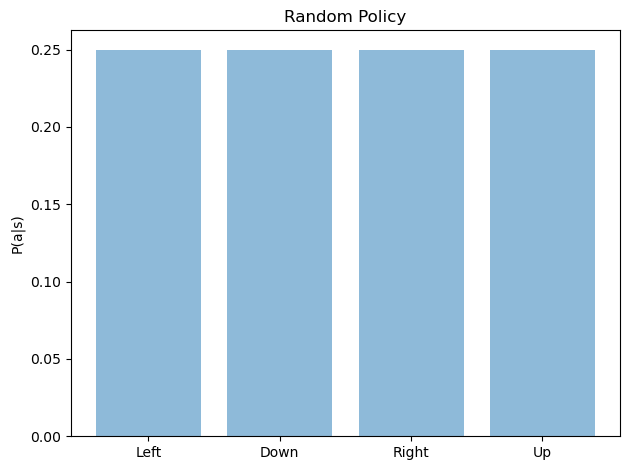

In [18]:
# Labels for the four actions, in order (index 0..3).
objects = ('Left', 'Down', 'Right', 'Up')
# Positions on the x-axis, one per action.
y_pos = np.arange(len(objects))

# Draw a bar for each action's probability.
plt.bar(y_pos, action_probabilities, alpha=0.5)
# Put the action names under the bars.
plt.xticks(y_pos, objects)
# Label the y-axis: probability of choosing each action.
plt.ylabel('P(a|s)')
# Give the chart a title.
plt.title('Random Policy')
# Tidy the spacing so labels are not cut off.
plt.tight_layout()

# Show the bar chart.
plt.show()

##### Use the policy to play an episode

The random policy has no idea where the holes are, so most of its episodes will end with a splash. That is fine: watching it fail is the baseline that every learning algorithm in the next notebooks will improve on.

In [19]:
# Run one full episode using a given policy and make a video of it.
def test_agent(environment, policy):
    # We will store one rendered picture per step to build the video.
    frames = []
    # Reset the lake and grab the first picture.
    state, info = environment.reset()
    done = False
    frames.append(environment.render())

    # Keep acting until the episode ends (gift, hole, or time limit).
    while not done:
        # Ask the policy for the action probabilities in this state.
        action_probs = policy(state)
        # Randomly pick ONE action (an integer) according to those probabilities.
        action = np.random.choice(4, p=action_probs)
        # Apply the action and read the result (five values in Gymnasium).
        next_state, reward, terminated, truncated, extra_info = environment.step(action)
        # Combine the ending flags.
        done = terminated or truncated
        # Capture a picture of the new state and store it.
        img = environment.render()
        frames.append(img)
        # The landing square becomes the current square.
        state = next_state

    # Turn the stored frames into a playable video.
    return display_video(frames)


# Watch the random policy try to solve the lake.
test_agent(env, random_policy)

NameError: name 'display_video' is not defined